# FAM Science-CCD Wavefront Outlier Fits (v1)

**Author:** Aaron Roodman
**Date Created:** 2026-09-22
**Last Modified:** 2026-09-22
**Status:** In Progress
**Keywords:** AOS, FAM, Danish, wavefront, outliers, quality cut, nMAD

## Description

Development of a cut to identify and remove individual bad donut wavefront fits in
Full Array Mode (FAM) science-CCD data. Across one Charge-Coupled Device (CCD) the
optical wavefront varies slowly with field angle, so the donut fits on one CCD in one
visit should all be close to their common median. A fit far from that median is a
failure of the fit, not a property of the optics.

Key functionality:
1. Per-CCD, per-visit median and normalized median absolute deviation (nMAD) of the
   per-donut wavefront deviation, for each Noll Zernike term.
2. Distribution of that nMAD per Zernike term, setting the scale of the intra-CCD
   scatter.
3. A robust z-score per donut — its distance from its own CCD's median in units of
   that CCD's nMAD — and a fixed absolute wavefront threshold, as two candidate cuts.
4. Fit details printed for the largest outliers, to characterize what a bad fit looks
   like.

**Output:** Figures inline; a per-donut flag table written to
`output/fam_processing/<param_set>/wavefront_outliers.parquet`.

**References:**
- `aos/docs/studies/fam_processing.md`
- `aos/code/fam_processing/blitz_reader.py` — the recast that produced the input table


## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-22 | Aaron Roodman | Initial version |


## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access](#data)
5. [Per-CCD Median and nMAD](#perccd)
6. [nMAD per Zernike Term](#nmadplots)
7. [Outlier Identification](#outliers)
8. [Fit Details of the Worst Outliers](#details)
9. [Candidate Cut](#cut)


<a id='params'></a>
## Parameters

`min_donuts_per_ccd` is the minimum number of donut fits a CCD must carry in a visit
before its median and nMAD are trusted. `z_threshold` is the robust z-score above which
a donut is flagged: the distance from its own CCD's median, in units of that CCD's nMAD,
maximized over Noll terms — dimensionless. `fixed_threshold_um` flags any donut whose
wavefront deviation exceeds it in any single Noll Zernike, in micrometres of wavefront.


In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================

param_set = 'danish_1_3_test'   # output/fam_processing/<param_set>/donuts.parquet

min_donuts_per_ccd = 5          # minimum donut fits per CCD per visit (count)
z_threshold = 20.0             # robust z-score cut (dimensionless)
fixed_threshold_um = 5.0        # absolute wavefront cut (um of wavefront, any Noll)

n_worst_to_print = 12           # how many worst outlier fits to tabulate
max_visits = None               # None = all visits; an int truncates for a quick look

coord_sys = 'OCS'               # frame of the wavefront deviation: OCS or CCS
write_parquet = True            # write the per-donut flag table

# Deviation column: zk_<frame> minus the batoid design intrinsic, per donut,
# in micrometres of wavefront.
dev_column = f'zk_deviation_{coord_sys}'


<a id='setup'></a>
## Setup & Imports


In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

%matplotlib inline

# Walk up to the topic directory, which works at any notebook depth
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))      # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))

from common.utils import nmad

table_dir = _TOPIC / 'output' / 'fam_processing' / param_set
donut_path = table_dir / 'donuts.parquet'
visit_path = table_dir / 'visits.parquet'
print(f'topic     {_TOPIC}')
print(f'donuts    {donut_path}  ({donut_path.stat().st_size / 1e9:.2f} GB)')


topic     /sdf/home/r/roodman/notebooks/rubin-work/aos
donuts    /sdf/home/r/roodman/notebooks/rubin-work/aos/output/fam_processing/danish_1_3_test/donuts.parquet  (5.06 GB)


<a id='functions'></a>
## Helper Functions


In [3]:
def nmad_axis0(a, min_n=3):
    """Column-wise normalized median absolute deviation of a 2-D array.

    The vectorized equivalent of `common.utils.nmad` applied to each column, which
    matters here because it is evaluated once per CCD per visit per Noll term.

    Parameters
    ----------
    a : `numpy.ndarray`, (n_donut, n_noll)
        Wavefront deviation per donut per Noll Zernike, in micrometres of wavefront.
    min_n : `int`, optional
        Return NaN for a column with fewer than this many finite values.

    Returns
    -------
    sigma : `numpy.ndarray`, (n_noll,)
        Robust scatter per Noll term, in micrometres of wavefront.
    median : `numpy.ndarray`, (n_noll,)
        Median per Noll term, in micrometres of wavefront.
    """
    a = np.asarray(a, float)
    med = np.nanmedian(a, axis=0)
    sigma = 1.4826 * np.nanmedian(np.abs(a - med), axis=0)
    n_finite = np.sum(np.isfinite(a), axis=0)
    sigma = np.where(n_finite >= min_n, sigma, np.nan)
    return sigma, med


def visit_ccd_stats(dev, detector, min_donuts):
    """Per-CCD median, nMAD and per-donut robust z-score for one visit.

    Parameters
    ----------
    dev : `numpy.ndarray`, (n_donut, n_noll)
        Per-donut wavefront deviation, in micrometres of wavefront.
    detector : `numpy.ndarray` of `str`, (n_donut,)
        Detector name per donut, e.g. ``'R01_S01'``.
    min_donuts : `int`
        Minimum donut fits for a CCD to be used.

    Returns
    -------
    stats : `list` of `tuple`
        One ``(detector, n_donuts, median, nmad)`` per used CCD; `median` and `nmad`
        are arrays over Noll terms, in micrometres of wavefront.
    zscore : `numpy.ndarray`, (n_donut, n_noll)
        ``|dev - median_CCD| / nmad_CCD``, dimensionless. NaN for donuts on a CCD
        with too few fits, and for Noll terms whose CCD nMAD is zero.
    """
    zscore = np.full(dev.shape, np.nan)
    stats = []
    for ccd, idx in pd.Series(detector).groupby(detector).indices.items():
        if len(idx) < min_donuts:
            continue
        sub = dev[idx]
        sigma, med = nmad_axis0(sub)
        safe = np.where(sigma > 0, sigma, np.nan)
        zscore[idx] = np.abs(sub - med) / safe
        stats.append((ccd, len(idx), med, sigma))
    return stats, zscore


In [4]:
# Cross-check nmad_axis0 against the shared scalar nmad on random data
_rng = np.random.default_rng(1234)
_a = _rng.normal(size=(200, 5))
_a[3, 2] = np.nan
_vec, _ = nmad_axis0(_a)
_ref = np.array([nmad(_a[:, j]) for j in range(_a.shape[1])])
print(f'max |nmad_axis0 - nmad| over 5 columns = '
      f'{np.nanmax(np.abs(_vec - _ref)):.3e} (dimensionless test data)')
assert np.allclose(_vec, _ref, equal_nan=True), 'nmad_axis0 disagrees with common.utils.nmad'
print('nmad_axis0 agrees with common.utils.nmad')


max |nmad_axis0 - nmad| over 5 columns = 0.000e+00 (dimensionless test data)
nmad_axis0 agrees with common.utils.nmad


<a id='data'></a>
## Data Access

The donut table carries one row group per visit, so the 5 GB file is read a visit at a
time and never lands in memory whole. The authoritative Noll index list comes from
`visits.parquet`; it is **not** contiguous — Z20 and Z21 are absent.

This table was written in `--mode mean`, so each row is one matched intra/extra donut
pair with the two sides of focus already averaged into a single wavefront. The fits
examined here are therefore per-donut-pair, not per side of focus. Separating the two
sides would need the table rebuilt with `run_blitz_mktable.py --mode intra` and
`--mode extra`.


In [5]:
visits = pd.read_parquet(visit_path)
noll = np.asarray(visits['nollIndices'].iloc[0], dtype=int)
noll_labels = [f'Z{n}' for n in noll]
print(f'{len(visits)} visits in {visit_path.name}')
print(f'{len(noll)} Noll terms: {list(noll)}')

pf = pq.ParquetFile(donut_path)
print(f'{pf.num_row_groups} row groups, {pf.metadata.num_rows} donut rows')

read_cols = ['day_obs', 'seq_num', 'detector', dev_column,
             'blur', 'snr', 'snr_intra', 'snr_extra',
             'chi2', 'lstsq_cost', 'lstsq_optimality', 'lstsq_status']
missing = [c for c in read_cols if c not in pf.schema_arrow.names]
assert not missing, f'columns absent from the donut table: {missing}'
print(f'reading {len(read_cols)} columns per row group')


966 visits in visits.parquet
21 Noll terms: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
966 row groups, 3155734 donut rows
reading 12 columns per row group


<a id='perccd'></a>
## Per-CCD Median and nMAD

One pass over the visits. For each visit and each CCD with at least
`min_donuts_per_ccd` fits, the median and nMAD of the per-donut wavefront deviation are
taken over the donuts on that CCD, per Noll Zernike. Each donut also gets a robust
z-score: its distance from its own CCD's median in units of that CCD's nMAD, maximized
over Noll terms.


In [6]:
n_rg = pf.num_row_groups if max_visits is None else min(max_visits, pf.num_row_groups)

ccd_rows = []      # per (visit, CCD, Noll): the median and nMAD
flag_rows = []     # per flagged donut: identity, diagnostics, z-score
n_donuts_total = 0
n_ccd_skipped = 0

for ig in range(n_rg):
    d = pf.read_row_group(ig, columns=read_cols).to_pandas()
    dev = np.asarray(np.stack(d[dev_column].to_numpy()), dtype=float)
    day_obs = int(d['day_obs'].iloc[0])
    seq_num = int(d['seq_num'].iloc[0])
    n_donuts_total += len(d)

    stats, zscore = visit_ccd_stats(dev, d['detector'].to_numpy(), min_donuts_per_ccd)
    n_ccd_skipped += d['detector'].nunique() - len(stats)

    for ccd, n_don, med, sigma in stats:
        for j, iZ in enumerate(noll):
            ccd_rows.append((day_obs, seq_num, ccd, int(iZ), n_don,
                             med[j], sigma[j]))

    # A CCD with too few donut fits leaves an all-NaN z-score row by
    # construction, so np.nanmax warns; that is expected, not a fault.
    with np.errstate(invalid='ignore'), \
         warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        z_max = np.nanmax(zscore, axis=1)
        dev_absmax = np.nanmax(np.abs(dev), axis=1)
        worst_z = noll[np.nanargmax(np.where(np.isfinite(zscore), zscore, -np.inf),
                                    axis=1)]
        worst_dev = noll[np.nanargmax(np.abs(dev), axis=1)]

    flag_z = z_max > z_threshold
    flag_fixed = dev_absmax > fixed_threshold_um
    sel = flag_z | flag_fixed
    if sel.any():
        sub = d.loc[sel, ['detector', 'blur', 'snr', 'snr_intra', 'snr_extra',
                          'chi2', 'lstsq_cost', 'lstsq_optimality',
                          'lstsq_status']].copy()
        sub.insert(0, 'day_obs', day_obs)
        sub.insert(1, 'seq_num', seq_num)
        sub['z_max'] = z_max[sel]
        sub['dev_absmax_um'] = dev_absmax[sel]
        sub['worst_noll_z'] = worst_z[sel]
        sub['worst_noll_dev'] = worst_dev[sel]
        sub['flag_zscore'] = flag_z[sel]
        sub['flag_fixed'] = flag_fixed[sel]
        flag_rows.append(sub)

    if (ig + 1) % 100 == 0 or ig + 1 == n_rg:
        print(f'  {ig + 1}/{n_rg} visits, {n_donuts_total} donuts, '
              f'{sum(len(f) for f in flag_rows)} flagged so far')

ccd_stats = pd.DataFrame(ccd_rows, columns=['day_obs', 'seq_num', 'detector', 'noll',
                                            'n_donuts', 'median_um', 'nmad_um'])
flagged = (pd.concat(flag_rows, ignore_index=True) if flag_rows
           else pd.DataFrame(columns=['day_obs', 'seq_num', 'detector']))
print(f'\n{len(ccd_stats)} (visit, CCD, Noll) rows over {n_rg} visits')
print(f'{n_ccd_skipped} (visit, CCD) pairs skipped for fewer than '
      f'{min_donuts_per_ccd} donut fits')
print(f'{len(flagged)} donuts flagged of {n_donuts_total} '
      f'({len(flagged) / n_donuts_total:.3e})')


  100/966 visits, 340931 donuts, 5714 flagged so far


  200/966 visits, 680573 donuts, 10455 flagged so far


  300/966 visits, 1014347 donuts, 16335 flagged so far


  400/966 visits, 1337780 donuts, 24037 flagged so far


  500/966 visits, 1672899 donuts, 27043 flagged so far


...

  700/966 visits, 2317594 donuts, 33926 flagged so far


  800/966 visits, 2651290 donuts, 38884 flagged so far


  900/966 visits, 2992020 donuts, 44689 flagged so far


  966/966 visits, 3155734 donuts, 48580 flagged so far



3565527 (visit, CCD, Noll) rows over 966 visits
3466 (visit, CCD) pairs skipped for fewer than 5 donut fits
48580 donuts flagged of 3155734 (1.539e-02)


### The intra-CCD scatter, per Noll term

The median over CCDs of the per-CCD nMAD is the typical spread of the donut fits within
one CCD in one visit — the scale against which an individual fit is judged discrepant.


In [7]:
summary = (ccd_stats.groupby('noll')['nmad_um']
           .agg(median='median',
                p16=lambda s: np.nanpercentile(s, 16),
                p84=lambda s: np.nanpercentile(s, 84),
                p99=lambda s: np.nanpercentile(s, 99),
                maximum='max', n='count')
           .reindex(noll))
summary.index = [f'Z{n}' for n in summary.index]
print('Per-CCD per-visit nMAD of the wavefront deviation [um of wavefront]')
print('n is the number of (visit, CCD) pairs contributing to each Noll term')
print(summary.to_string(float_format=lambda v: f'{v:.4f}'))


Per-CCD per-visit nMAD of the wavefront deviation [um of wavefront]
n is the number of (visit, CCD) pairs contributing to each Noll term
     median    p16    p84    p99  maximum       n
Z4   0.0198 0.0115 0.0375 0.0799   2.1785  169787
Z5   0.0556 0.0346 0.0881 0.1640   5.2119  169787
Z6   0.0557 0.0336 0.0924 0.1838   3.5615  169787
Z7   0.0429 0.0265 0.0698 0.1617   9.7701  169787
Z8   0.0387 0.0237 0.0643 0.1520   5.6845  169787
Z9   0.0365 0.0224 0.0606 0.1330   5.2938  169787
Z10  0.0363 0.0223 0.0601 0.1322   2.0641  169787
Z11  0.0041 0.0025 0.0064 0.0124   1.2760  169787
Z12  0.0138 0.0085 0.0223 0.0439   1.4159  169787
Z13  0.0127 0.0080 0.0199 0.0369   0.7307  169787
Z14  0.0134 0.0083 0.0222 0.0469   0.7725  169787
Z15  0.0130 0.0080 0.0216 0.0445   0.9259  169787
Z16  0.0076 0.0047 0.0127 0.0300   2.4941  169787
Z17  0.0083 0.0051 0.0139 0.0327   3.4550  169787
Z18  0.0072 0.0044 0.0120 0.0242   0.9302  169787
Z19  0.0072 0.0044 0.0121 0.0243   1.8272  169787
Z22  0.0016 0

<a id='nmadplots'></a>
## nMAD per Zernike Term


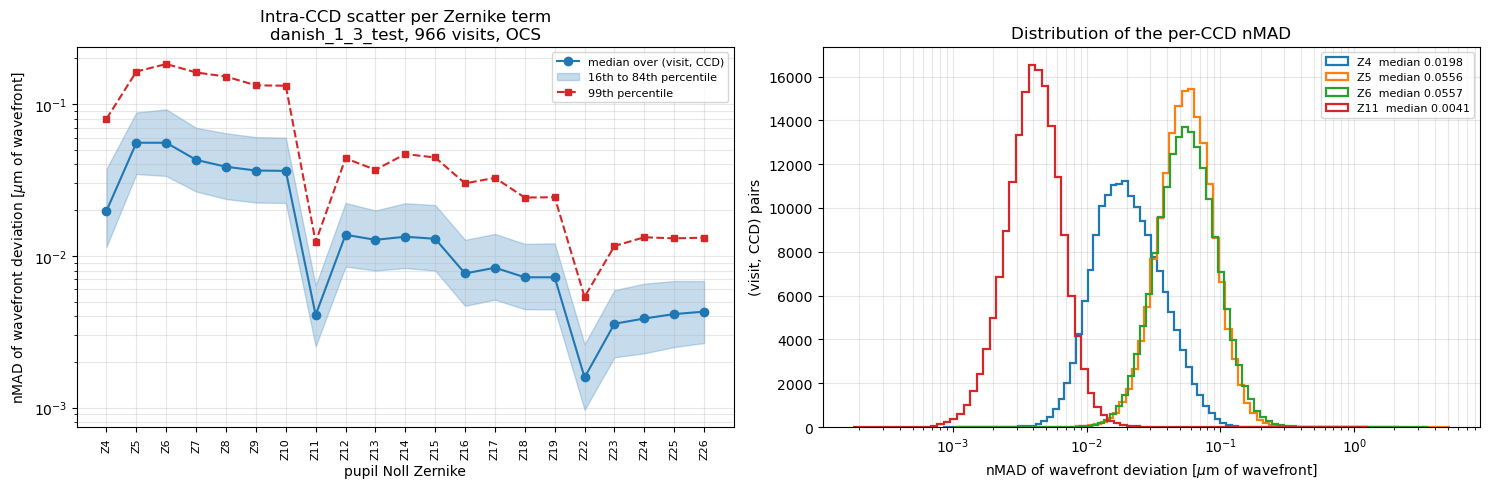

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
x = np.arange(len(noll))
ax.plot(x, summary['median'], 'o-', color='C0', label='median over (visit, CCD)')
ax.fill_between(x, summary['p16'], summary['p84'], alpha=0.25, color='C0',
                label='16th to 84th percentile')
ax.plot(x, summary['p99'], 's--', color='C3', ms=4, label='99th percentile')
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=90, fontsize=8)
ax.set_ylabel('nMAD of wavefront deviation [$\\mu$m of wavefront]')
ax.set_xlabel('pupil Noll Zernike')
ax.set_yscale('log')
ax.set_title(f'Intra-CCD scatter per Zernike term\n{param_set}, {n_rg} visits, '
             f'{coord_sys}')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=8)

ax = axes[1]
for iZ in [4, 5, 6, 11]:
    v = ccd_stats.loc[ccd_stats['noll'] == iZ, 'nmad_um'].to_numpy()
    v = v[np.isfinite(v) & (v > 0)]
    ax.hist(v, bins=np.logspace(np.log10(max(v.min(), 1e-4)), np.log10(v.max()), 80),
            histtype='step', lw=1.6, label=f'Z{iZ}  median {np.median(v):.4f}')
ax.set_xscale('log')
ax.set_xlabel('nMAD of wavefront deviation [$\\mu$m of wavefront]')
ax.set_ylabel('(visit, CCD) pairs')
ax.set_title('Distribution of the per-CCD nMAD')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


**Note on what the per-CCD nMAD can and cannot do.** The nMAD is robust by
construction, so a single catastrophic donut among the ~19 fits on a CCD barely moves
it — the per-CCD nMAD stays near its typical value even in visits containing a donut
wrong by thousands of micrometres of wavefront. The per-CCD nMAD therefore sets the
*scale*; it does not by itself *find* the outliers. Finding them is what the per-donut
robust z-score below does.


<a id='outliers'></a>
## Outlier Identification

Two candidate flags, both per donut:

- **robust z-score**: `|dev - median_CCD| / nMAD_CCD > z_threshold`, maximized over
  Noll terms. Scales with each CCD's own measured scatter.
- **fixed threshold**: `|dev| > fixed_threshold_um` in any single Noll Zernike. An
  absolute floor, independent of how noisy a CCD happens to be.


In [9]:
n_z = int(flagged['flag_zscore'].sum()) if len(flagged) else 0
n_f = int(flagged['flag_fixed'].sum()) if len(flagged) else 0
n_both = int((flagged['flag_zscore'] & flagged['flag_fixed']).sum()) if len(flagged) else 0

print(f'{n_donuts_total} donut fits over {n_rg} visits\n')
print(f'{"flag":36s} {"n":>8s} {"fraction":>11s}')
for lbl, n in [(f'robust z-score > {z_threshold:g} (dimensionless)', n_z),
               (f'|deviation| > {fixed_threshold_um:g} um of wavefront', n_f),
               ('both flags', n_both),
               ('either flag', len(flagged))]:
    print(f'{lbl:36s} {n:8d} {n / n_donuts_total:11.3e}')

if n_f:
    print(f'\n{n_both}/{n_f} of the fixed-threshold donuts are also caught by the '
          f'z-score cut')


3155734 donut fits over 966 visits

flag                                        n    fraction
robust z-score > 20 (dimensionless)     48438   1.535e-02
|deviation| > 5 um of wavefront          3997   1.267e-03
both flags                               3855   1.222e-03
either flag                             48580   1.539e-02

3855/3997 of the fixed-threshold donuts are also caught by the z-score cut


In [10]:
# How many visits and CCDs are touched, and the worst Noll terms
if len(flagged):
    nv = flagged.groupby(['day_obs', 'seq_num']).ngroups
    print(f'{nv} of {n_rg} visits contain at least one flagged donut '
          f'({nv / n_rg:.3f})')
    per_visit = flagged.groupby(['day_obs', 'seq_num']).size()
    print(f'flagged donuts per affected visit: median {per_visit.median():.0f}, '
          f'max {per_visit.max()}')
    print(f'\nNoll term driving the largest |deviation| (counts):')
    print(flagged['worst_noll_dev'].value_counts().head(8).to_string())
    print(f'\nDetectors most often flagged (counts):')
    print(flagged['detector'].value_counts().head(8).to_string())


966 of 966 visits contain at least one flagged donut (1.000)
flagged donuts per affected visit: median 49, max 486

Noll term driving the largest |deviation| (counts):
worst_noll_dev
6     10063
5      8773
7      8343
8      6906
4      6129
9      4211
10     3158
12      355

Detectors most often flagged (counts):
detector
R01_S01    883
R23_S10    496
R23_S20    474
R31_S02    435
R20_S20    416
R33_S01    407
R34_S02    403
R02_S22    399


<a id='details'></a>
## Fit Details of the Worst Outliers

The fit diagnostics carried per donut, for the largest absolute wavefront deviations,
against the median of the donuts that pass both flags. `blur` is in arcseconds; `snr`
is dimensionless; `lstsq_cost` and `lstsq_optimality` are the least-squares objective
and optimality measure reported by Danish, in its own internal units.


In [11]:
diag_cols = ['blur', 'snr', 'snr_intra', 'snr_extra', 'chi2',
             'lstsq_cost', 'lstsq_optimality', 'lstsq_status']

if len(flagged):
    worst = flagged.sort_values('dev_absmax_um', ascending=False).head(n_worst_to_print)
    show = ['day_obs', 'seq_num', 'detector', 'dev_absmax_um', 'worst_noll_dev',
            'z_max', 'worst_noll_z', 'blur', 'snr', 'lstsq_cost',
            'lstsq_optimality', 'lstsq_status']
    print(f'The {len(worst)} largest |wavefront deviation| fits')
    print('dev_absmax_um in um of wavefront; z_max dimensionless; blur in arcsec\n')
    print(worst[show].to_string(index=False,
                                float_format=lambda v: f'{v:.4g}'))



The 12 largest |wavefront deviation| fits
dev_absmax_um in um of wavefront; z_max dimensionless; blur in arcsec

 day_obs  seq_num detector  dev_absmax_um  worst_noll_dev     z_max  worst_noll_z  blur   snr  lstsq_cost  lstsq_optimality  lstsq_status
20260316      746  R20_S22           7704               5 1.137e+05             5 2.978 893.1   1.506e+05          2.04e+09            -1
20260331      256  R34_S02           7258               6 6.605e+04            22  2.09   192   1.245e+04         5.402e+07            -1
20260401      388  R01_S01           2746               5      8605             5 1.054 333.6   7.007e+04             2.132            -1
20260317      318  R10_S20           2663               9 1.076e+05            14 2.987 478.4   6.183e+04         4.145e+08            -1
20260327      206  R23_S22           2497               6 2.654e+04             6  2.65 544.9   8.032e+04         1.305e+08            -1
20260331      304  R42_S20           2387               9 1

In [12]:
# Unflagged reference medians need a second pass, since only flagged rows were kept.
# Sample a subset of visits to keep this cheap.
rng = np.random.default_rng(0)
sample_rg = sorted(rng.choice(n_rg, size=min(40, n_rg), replace=False).tolist())
ref = []
for ig in sample_rg:
    d = pf.read_row_group(ig, columns=read_cols).to_pandas()
    dev = np.asarray(np.stack(d[dev_column].to_numpy()), dtype=float)
    _, zscore = visit_ccd_stats(dev, d['detector'].to_numpy(), min_donuts_per_ccd)
    with np.errstate(invalid='ignore'), warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        keep = ~((np.nanmax(zscore, axis=1) > z_threshold)
                 | (np.nanmax(np.abs(dev), axis=1) > fixed_threshold_um))
    ref.append(d.loc[keep, diag_cols])
ref = pd.concat(ref, ignore_index=True)

print(f'unflagged reference from {len(sample_rg)} sampled visits, {len(ref)} donuts\n')
print(f'{"quantity":20s} {"flagged":>13s} {"unflagged":>13s} {"ratio":>8s}')
for c in diag_cols:
    fv = pd.to_numeric(flagged[c], errors='coerce') if len(flagged) else pd.Series(dtype=float)
    gv = pd.to_numeric(ref[c], errors='coerce')
    mf = np.nanmedian(fv) if len(fv) and np.isfinite(fv).any() else np.nan
    mg = np.nanmedian(gv) if np.isfinite(gv).any() else np.nan
    rat = mf / mg if (np.isfinite(mf) and np.isfinite(mg) and mg != 0) else np.nan
    print(f'{c:20s} {mf:13.4g} {mg:13.4g} {rat:8.3g}')
print('\nblur in arcsec; snr dimensionless; chi2 and lstsq_* in Danish internal units')


unflagged reference from 40 sampled visits, 131191 donuts

quantity                   flagged     unflagged    ratio
blur                         1.245        0.8935     1.39
snr                            912          2912    0.313
snr_intra                    920.2          2922    0.315
snr_extra                      900          2899     0.31
chi2                           nan           nan      nan
lstsq_cost               2.237e+04     3.523e+04    0.635
lstsq_optimality         1.119e+09     9.123e+08     1.23
lstsq_status                    -1            -1        1

blur in arcsec; snr dimensionless; chi2 and lstsq_* in Danish internal units


### Are blur and signal-to-noise on their own enough to predict a bad fit?

If the bad fits were simply the high-blur, low-signal-to-noise donuts, a cut on those
alone would remove them without any reference to the wavefront.


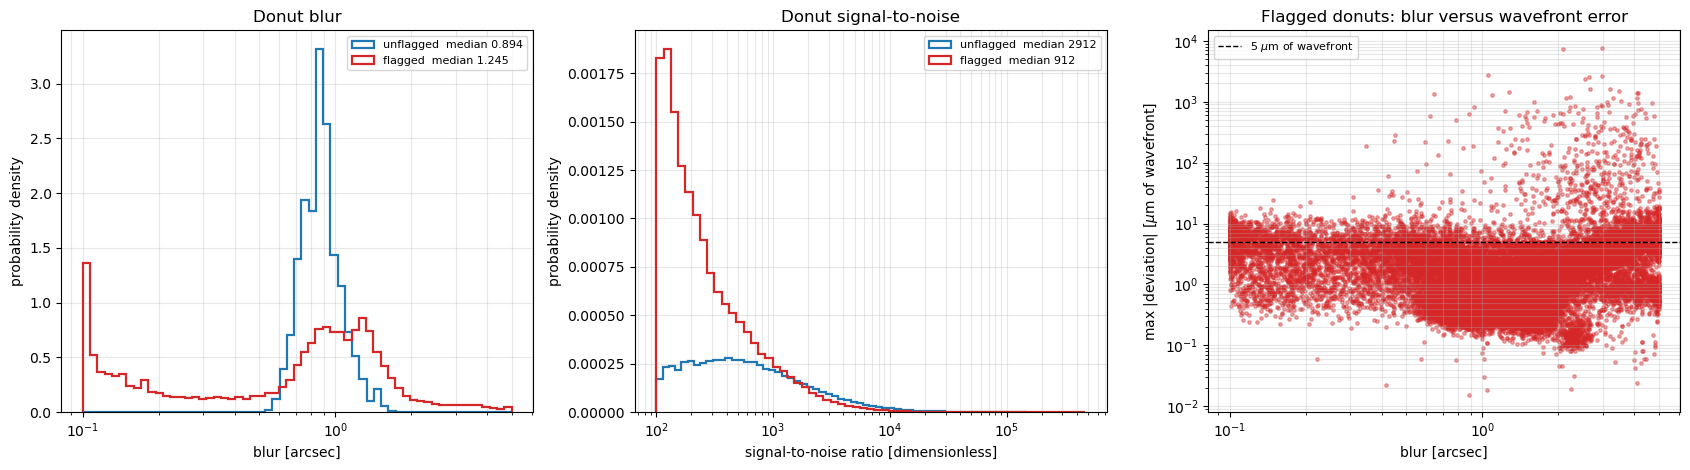

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

ax = axes[0]
for lbl, v, c in [('unflagged', pd.to_numeric(ref['blur'], errors='coerce'), 'C0'),
                  ('flagged', pd.to_numeric(flagged['blur'], errors='coerce')
                   if len(flagged) else pd.Series(dtype=float), 'C3')]:
    v = v[np.isfinite(v) & (v > 0)]
    if len(v):
        ax.hist(v, bins=np.logspace(np.log10(v.min()), np.log10(v.max()), 60),
                histtype='step', lw=1.6, density=True, color=c,
                label=f'{lbl}  median {np.median(v):.3f}')
ax.set_xscale('log')
ax.set_xlabel('blur [arcsec]')
ax.set_ylabel('probability density')
ax.set_title('Donut blur')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

ax = axes[1]
for lbl, v, c in [('unflagged', pd.to_numeric(ref['snr'], errors='coerce'), 'C0'),
                  ('flagged', pd.to_numeric(flagged['snr'], errors='coerce')
                   if len(flagged) else pd.Series(dtype=float), 'C3')]:
    v = v[np.isfinite(v) & (v > 0)]
    if len(v):
        ax.hist(v, bins=np.logspace(np.log10(v.min()), np.log10(v.max()), 60),
                histtype='step', lw=1.6, density=True, color=c,
                label=f'{lbl}  median {np.median(v):.0f}')
ax.set_xscale('log')
ax.set_xlabel('signal-to-noise ratio [dimensionless]')
ax.set_ylabel('probability density')
ax.set_title('Donut signal-to-noise')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

ax = axes[2]
if len(flagged):
    fb = pd.to_numeric(flagged['blur'], errors='coerce')
    fd = pd.to_numeric(flagged['dev_absmax_um'], errors='coerce')
    ok = np.isfinite(fb) & np.isfinite(fd) & (fb > 0)
    ax.scatter(fb[ok], fd[ok], s=6, alpha=0.4, color='C3')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.axhline(fixed_threshold_um, color='k', ls='--', lw=1,
               label=f'{fixed_threshold_um:g} $\\mu$m of wavefront')
    ax.legend(fontsize=8)
ax.set_xlabel('blur [arcsec]')
ax.set_ylabel('max |deviation| [$\\mu$m of wavefront]')
ax.set_title('Flagged donuts: blur versus wavefront error')
ax.grid(alpha=0.3, which='both')

fig.tight_layout()
plt.show()


In [14]:
# Purity and efficiency of a blur-only cut, over the sampled visits
if len(flagged):
    for t in (1.5, 2.0, 2.5, 3.0):
        fb = pd.to_numeric(flagged['blur'], errors='coerce')
        gb = pd.to_numeric(ref['blur'], errors='coerce')
        eff = np.nanmean(fb > t)
        fpr = np.nanmean(gb > t)
        print(f'blur > {t:.1f} arcsec: catches {eff:.3f} of flagged donuts, '
              f'removes {fpr:.4f} of unflagged donuts')
    print('\nA blur-only cut is not sufficient on its own: most flagged donuts sit '
          'at ordinary blur.')


blur > 1.5 arcsec: catches 0.317 of flagged donuts, removes 0.0111 of unflagged donuts
blur > 2.0 arcsec: catches 0.183 of flagged donuts, removes 0.0004 of unflagged donuts
blur > 2.5 arcsec: catches 0.135 of flagged donuts, removes 0.0001 of unflagged donuts
blur > 3.0 arcsec: catches 0.102 of flagged donuts, removes 0.0001 of unflagged donuts

A blur-only cut is not sufficient on its own: most flagged donuts sit at ordinary blur.


<a id='cut'></a>
## Candidate Cut

The per-donut flag table is written so the cut can be applied downstream without
recomputing it. Columns: `day_obs`, `seq_num`, `detector`, the two flags, the robust
z-score (dimensionless), the largest absolute wavefront deviation in micrometres of
wavefront, and the Noll term responsible.


In [15]:
out_path = table_dir / 'wavefront_outliers.parquet'
if write_parquet and len(flagged):
    meta = dict(param_set=param_set, coord_sys=coord_sys,
                min_donuts_per_ccd=min_donuts_per_ccd,
                z_threshold=z_threshold,
                fixed_threshold_um=fixed_threshold_um,
                n_visits=n_rg, n_donuts_total=n_donuts_total)
    flagged.attrs.update(meta)
    flagged.to_parquet(out_path, index=False)
    print(f'wrote {out_path}  ({out_path.stat().st_size / 1e6:.2f} MB, '
          f'{len(flagged)} flagged donuts)')
    for k, v in meta.items():
        print(f'  {k} = {v}')
else:
    print('not written (write_parquet False, or no donuts flagged)')


wrote /sdf/home/r/roodman/notebooks/rubin-work/aos/output/fam_processing/danish_1_3_test/wavefront_outliers.parquet  (4.00 MB, 48580 flagged donuts)
  param_set = danish_1_3_test
  coord_sys = OCS
  min_donuts_per_ccd = 5
  z_threshold = 20.0
  fixed_threshold_um = 5.0
  n_visits = 966
  n_donuts_total = 3155734


### Findings

On `danish_1_3_test`: 3,155,734 donut fits over 966 visits, 169,787 (visit, CCD) pairs
used, 21 Noll terms.

**The donuts on one CCD do agree closely.** The median over (visit, CCD) pairs of the
per-CCD nMAD of the wavefront deviation is 0.0198 µm of wavefront on Z4 Defocus, 0.0556
on Z5 Astig45, 0.0557 on Z6 Astig0 and 0.0041 on Z11 Spherical. Those are 15 to 20 times
smaller than the same quantity taken over the whole focal plane (0.384 µm of wavefront
on Z4, 0.324 on Z5), because the CCD-level median absorbs the field dependence. The
intra-CCD scatter is therefore a sharp scale against which to judge an individual fit.

**The per-CCD nMAD does not itself find the outliers.** Its 99th percentile stays at
0.0799 µm of wavefront on Z4 and 0.164 on Z5, only about 4 times the median, while the
maximum reaches 2.18 and 5.21. A single catastrophic donut among the ~19 fits on a CCD
moves the nMAD hardly at all — that is what robustness means. A cut on the per-CCD nMAD
alone, at any threshold well above the typical value, fires on almost nothing.

**The per-donut robust z-score does find them.** Flagging `|dev - median_CCD| /
nMAD_CCD > 20` (dimensionless, maximized over Noll terms) selects 48,438 donuts,
1.535e-02 of the sample. The fixed threshold `|dev| > 5 µm of wavefront` in any single
Noll term selects 3,997 donuts, 1.267e-03. The two are nearly nested: 3,855 of the 3,997
fixed-threshold donuts, 96.4 %, are also caught by the z-score. Either flag selects
48,580 donuts, 1.539e-02.

**The worst fits are wrong by thousands of micrometres of wavefront.** The largest is
7,704 µm of wavefront on Z5 Astig45 (`day_obs` 20260316, `seq_num` 746, detector
R20_S22), followed by 7,258 on Z6 Astig0 and 2,746 on Z5. For scale, the per-CCD nMAD on
those terms is about 0.056 µm of wavefront, so the worst fit sits at a robust z-score of
1.14e+05.

**The astigmatism and coma terms dominate.** The Noll term carrying the largest absolute
deviation is Z6 Astig0 for 10,063 flagged donuts, Z5 Astig45 for 8,773, Z7 Coma_y for
8,343, Z8 Coma_x for 6,906 and Z4 Defocus for 6,129. The high-order terms are almost
never the worst.

**Every visit is affected, but only lightly.** All 966 visits contain at least one
flagged donut, with a median of 49 flagged donuts per visit against roughly 3,270 fits
per visit, and a maximum of 486. Detector R01_S01 is flagged most often, 883 times.

**Blur and signal-to-noise alone are not a sufficient cut.** Flagged donuts have a
median blur of 1.245 arcsec against 0.837 for unflagged, and the very worst fits sit at
2.0 to 4.2 arcsec. But a blur cut is a poor selector: `blur > 2.0 arcsec` catches only
0.183 of the flagged donuts while removing 4e-04 of the good ones, and `blur > 1.5
arcsec` catches 0.317 while removing 1.11e-02. Most bad fits occur at ordinary blur, so
the cut has to look at the wavefront itself.

**`chi2` and `lstsq_status` are unusable here.** `chi2` is NaN on every row of this
table and `lstsq_status` is uniformly −1, so neither can contribute to a cut.
`lstsq_cost` and `lstsq_optimality` do vary but span many orders of magnitude on both
good and bad fits.

**Recommended cut.** The robust z-score against the CCD median is the primary
discriminant, since it adapts to each CCD's own scatter and catches 96.4 % of what the
absolute threshold finds. Retaining the fixed 5 µm of wavefront threshold as well costs
only 142 additional donuts, 1.4e-04 of the removed set, and guards against the case
where a whole CCD fails together and inflates its own nMAD. Removing 1.54e-02 of donuts
is a small price against per-donut deviations reaching 7,704 µm of wavefront.

**Caveat on the side of focus.** This table was built in `--mode mean`, so each row is a
matched intra/extra pair with the two sides already averaged. Which side of focus failed
cannot be determined here; that needs `run_blitz_mktable.py --mode intra` and
`--mode extra`.
